# N-CMAPSS DS01 -- Exploration

Dataset: NASA N-CMAPSS, subset DS01 (single degradation mode: High-Pressure Turbine
efficiency modifier). Unlike the older C-MAPSS benchmark, degradation here is driven by
*real recorded flight-condition profiles* (altitude, Mach, throttle resolver angle, inlet
temperature) rather than a handful of fixed operating points.

This notebook covers:
1. Sensor and channel overview
2. What a real flight-condition profile looks like (raw, one flight)
3. Flight-condition variability across the fleet (the "real conditions" claim, with evidence)
4. Degradation trajectories per unit
5. Data quality checks
6. Unit-level train/val/test split

Citation: Chao, M., Kulkarni, C., Goebel, K., & Fink, O. (2021). *Aircraft Engine
Run-to-Failure Dataset under real flight conditions*, NASA Ames Prognostics Data Repository.

In [1]:
import sys
sys.path.insert(0, "../src")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from data_loading import load_raw, raw_to_frame, load_cycle_level
from splits import TRAIN_UNITS, VAL_UNITS, TEST_UNITS, UNIT_TO_FLIGHT_CLASS

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)

## 1. Sensor and channel overview

The raw file stores one row per timestep within a flight (1 Hz-ish sampling), grouped into:

| Group | Meaning | Measurable on a real aircraft? |
|---|---|---|
| `W` | flight conditions: altitude, Mach, throttle resolver angle, inlet temp (T2) | yes |
| `X_s` | 14 physical sensor channels (temperatures, pressures, speeds, fuel flow) | yes |
| `X_v` | 14 virtual/derived channels (internal flows, stall margins, bleed ratio) | **no** -- simulation-only |
| `T` | 10 engine health parameters (efficiency/flow modifiers per module) | **no** -- ground truth used to *generate* the simulation |
| `A` | auxiliary: unit, cycle, flight class `Fc` (1/2/3), health-state flag `hs` | -- |
| `Y` | remaining useful life (RUL) in cycles, constant within a cycle | target |

This distinction matters for modeling: a deployable model can only ever see `W` and `X_s`.
`X_v` and `T` exist because this is a simulation with full internal visibility -- using them
as features would leak information no real sensor provides. We keep them here only for
exploration (e.g. `T`'s `HPT_eff_mod` is the actual degradation signal that drives everything
else, so it's useful for sanity-checking trends).

In [2]:
raw_dev = load_raw("dev")
for group in ["A", "W", "X_s", "X_v", "T"]:
    print(f"{group:4s} columns: {raw_dev[f'{group}_cols']}")
print()
print("dev rows (all timesteps, all units):", raw_dev["A"].shape[0])

A    columns: ['unit', 'cycle', 'Fc', 'hs']
W    columns: ['alt', 'Mach', 'TRA', 'T2']
X_s  columns: ['T24', 'T30', 'T48', 'T50', 'P15', 'P2', 'P21', 'P24', 'Ps30', 'P40', 'P50', 'Nf', 'Nc', 'Wf']
X_v  columns: ['T40', 'P30', 'P45', 'W21', 'W22', 'W25', 'W31', 'W32', 'W48', 'W50', 'SmFan', 'SmLPC', 'SmHPC', 'phi']
T    columns: ['fan_eff_mod', 'fan_flow_mod', 'LPC_eff_mod', 'LPC_flow_mod', 'HPC_eff_mod', 'HPC_flow_mod', 'HPT_eff_mod', 'HPT_flow_mod', 'LPT_eff_mod', 'LPT_flow_mod']

dev rows (all timesteps, all units): 4906636


## 2. What a real flight-condition profile looks like

One flight (one unit, one cycle) from the dev set, raw resolution. This is the climb /
cruise / descent shape of an actual flight -- the whole reason N-CMAPSS is a step up from
C-MAPSS's fixed operating points.

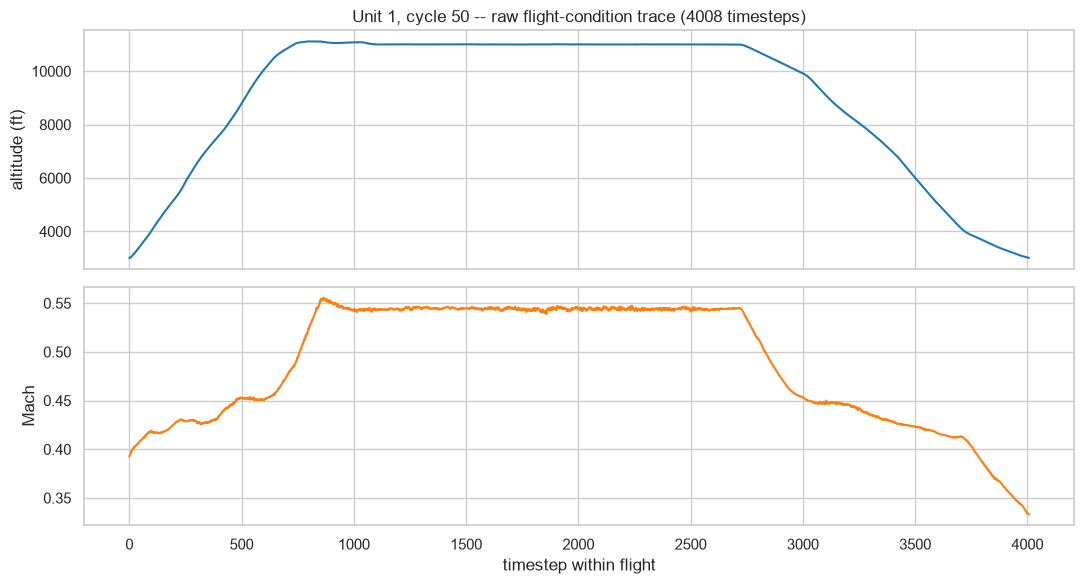

In [3]:
df_dev_raw = raw_to_frame(raw_dev)
one_flight = df_dev_raw[(df_dev_raw["unit"] == 1) & (df_dev_raw["cycle"] == 50)].reset_index(drop=True)

fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
t = np.arange(len(one_flight))
axes[0].plot(t, one_flight["alt"], color="tab:blue")
axes[0].set_ylabel("altitude (ft)")
axes[1].plot(t, one_flight["Mach"], color="tab:orange")
axes[1].set_ylabel("Mach")
axes[1].set_xlabel("timestep within flight")
axes[0].set_title(f"Unit 1, cycle 50 -- raw flight-condition trace ({len(one_flight)} timesteps)")
plt.tight_layout()
plt.show()

## 3. Flight-condition variability across the fleet

Each unit is assigned a fixed *flight class* (`Fc` 1/2/3 -- short/medium/long-haul profiles),
but even within a single flight, conditions vary substantially. We aggregate each flight down
to one row (per unit, per cycle) and look at the within-flight range of altitude and Mach.

This is the evidence for the "real conditions" claim: DS01 isn't a handful of fixed set
points, it's continuously varying flight profiles, and the three flight classes trace out
clearly separated but internally variable altitude/Mach envelopes.

In [4]:
dev = load_cycle_level("dev")
test = load_cycle_level("test")
dev["split"] = "dev"
test["split"] = "test"
combined = pd.concat([dev, test], ignore_index=True)
combined["flight_class"] = combined["unit"].map(UNIT_TO_FLIGHT_CLASS)
combined.shape

(894, 104)

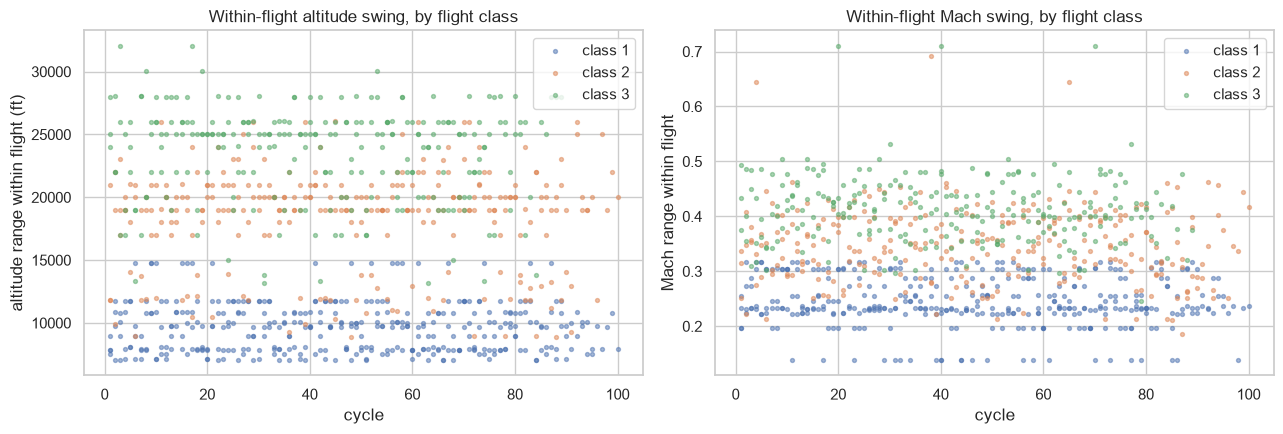

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for fc in sorted(combined["flight_class"].unique()):
    sub = combined[combined["flight_class"] == fc]
    axes[0].scatter(sub["cycle"], sub["alt_max"] - sub["alt_min"], s=8, alpha=0.5, label=f"class {fc}")
    axes[1].scatter(sub["cycle"], sub["Mach_max"] - sub["Mach_min"], s=8, alpha=0.5, label=f"class {fc}")
axes[0].set_xlabel("cycle"); axes[0].set_ylabel("altitude range within flight (ft)")
axes[1].set_xlabel("cycle"); axes[1].set_ylabel("Mach range within flight")
axes[0].set_title("Within-flight altitude swing, by flight class")
axes[1].set_title("Within-flight Mach swing, by flight class")
axes[0].legend(); axes[1].legend()
plt.tight_layout()
plt.show()

## 4. Degradation trajectories per unit

Two views of the same underlying degradation:

- **Left**: `T50` (LPT outlet temperature), a real measured sensor. It trends upward with
  degradation but is noisy cycle-to-cycle because it's confounded by flight conditions --
  a hotter/higher-altitude flight raises `T50` independent of engine health. This is exactly
  why cycle-based feature engineering (Phase 3) needs to account for operating condition,
  not just raw sensor trend.
- **Right**: `HPT_eff_mod`, the ground-truth health parameter (ordinarily invisible in
  reality, included here for validation). It shows the actual degradation curve: flat, then
  an accelerating decline -- the textbook run-to-failure shape, and confirmation that DS01's
  single degradation mode (HPT efficiency) is doing what the documentation says it does.

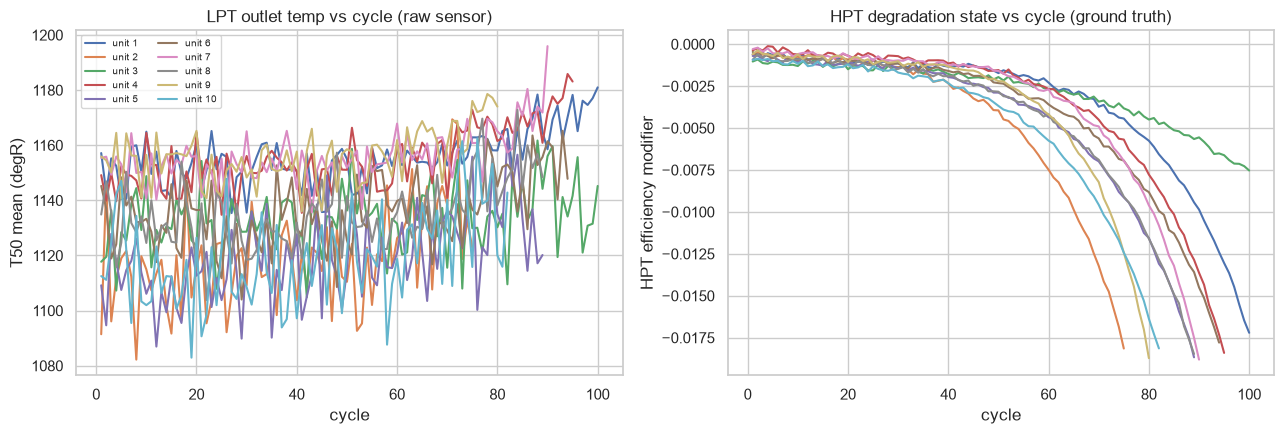

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for u in sorted(combined["unit"].unique()):
    sub = combined[combined["unit"] == u]
    axes[0].plot(sub["cycle"], sub["T50_mean"], label=f"unit {u}")
    axes[1].plot(sub["cycle"], sub["HPT_eff_mod_mean"], label=f"unit {u}")
axes[0].set_xlabel("cycle"); axes[0].set_ylabel("T50 mean (degR)"); axes[0].set_title("LPT outlet temp vs cycle (raw sensor)")
axes[1].set_xlabel("cycle"); axes[1].set_ylabel("HPT efficiency modifier"); axes[1].set_title("HPT degradation state vs cycle (ground truth)")
axes[0].legend(fontsize=7, ncol=2)
plt.tight_layout()
plt.show()

### RUL vs cycle, per unit

By construction RUL decreases one-for-one with cycle. Different units run to failure at
different lifetimes (75-100 cycles across dev, 80-90 across test) -- there's no fixed
end-of-life cycle count, which is what makes RUL regression a real prediction problem
rather than a lookup.

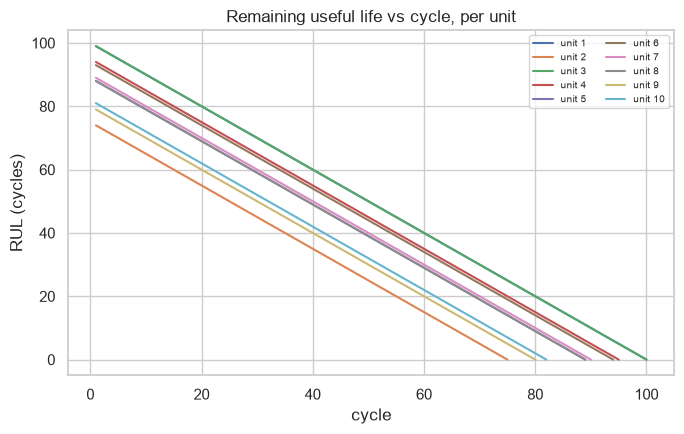

In [7]:
fig, ax = plt.subplots(figsize=(7, 4.5))
for u in sorted(combined["unit"].unique()):
    sub = combined[combined["unit"] == u]
    ax.plot(sub["cycle"], sub["RUL"], label=f"unit {u}")
ax.set_xlabel("cycle"); ax.set_ylabel("RUL (cycles)")
ax.set_title("Remaining useful life vs cycle, per unit")
ax.legend(fontsize=7, ncol=2)
plt.tight_layout()
plt.show()

## 5. Data quality checks

- No missing values in any aggregated column.
- RUL is monotonically non-increasing within every unit (sanity check: a unit's remaining
  life can't go up as cycles pass).
- Row counts per unit-cycle are consistent with the raw per-timestep counts (no dropped
  flights during aggregation).

In [8]:
na_counts = combined.isna().sum()
print("Columns with missing values:", na_counts[na_counts > 0].to_dict() or "none")

print()
print("RUL monotonic non-increasing per unit:")
for u in sorted(combined["unit"].unique()):
    sub = combined[combined["unit"] == u].sort_values("cycle")
    ok = (sub["RUL"].diff().dropna() <= 0).all()
    print(f"  unit {u:>2d}: {ok}")

Columns with missing values: none

RUL monotonic non-increasing per unit:
  unit  1: True
  unit  2: True
  unit  3: True
  unit  4: True
  unit  5: True
  unit  6: True
  unit  7: True
  unit  8: True
  unit  9: True
  unit 10: True


In [9]:
summary = combined.groupby(["split", "unit", "flight_class"]).agg(
    n_cycles=("cycle", "nunique"),
    min_RUL=("RUL", "min"),
    max_RUL=("RUL", "max"),
    total_timesteps=("n_timesteps", "sum"),
)
summary

n_cycles  min_RUL  max_RUL  total_timesteps
split unit flight_class                                             
dev   1    1                  100        0       99           433325
      2    3                   75        0       74          1049088
      3    2                  100        0       99           893054
      4    1                   95        0       94           414172
      5    3                   89        0       88          1280147
      6    2                   94        0       93           836850
test  7    1                   90        0       89           392585
      8    2                   89        0       88           800294
      9    1                   80        0       79           351683
      10   3                   82        0       81          1190670

## 6. Unit-level train/val/test split

NASA ships DS01 pre-split by unit: **dev** (units 1-6) and **test** (units 7-10), already
unit-disjoint -- no engine appears in both, so there's no leakage between them. The test
split stays held out untouched until final model evaluation in Phase 3.

Within dev, each unit has one fixed flight class, two units per class. To carve out a
validation set without leaking units and without losing any flight class from either side,
we hold out one unit per class for validation:

| Flight class | Train unit | Val unit |
|---|---|---|
| 1 | 1 | 4 |
| 2 | 3 | 6 |
| 3 | 2 | 5 |

So: `TRAIN_UNITS = (1, 2, 3)`, `VAL_UNITS = (4, 5, 6)`, `TEST_UNITS = (7, 8, 9, 10)`
(defined in `src/splits.py`, reused by the training pipeline in Phase 3 so the split is
identical everywhere).

In [10]:
split_check = combined.groupby("unit").agg(flight_class=("flight_class", "first"), n_cycles=("cycle", "nunique"))
split_check["role"] = split_check.index.map(
    lambda u: "train" if u in TRAIN_UNITS else "val" if u in VAL_UNITS else "test"
)
split_check

,flight_class,n_cycles,role
unit,,,
1,1,100,train
2,3,75,train
3,2,100,train
4,1,95,val
5,3,89,val
6,2,94,val
7,1,90,test
8,2,89,test
9,1,80,test
